# Phase 1 — Zodiac Star Spectral Analysis
## Physics-Informed Spectral State Estimator

**Goal**: Independently analyse the stellar spectrum of every principal star across all 12 zodiac constellations.

**Pipeline per star**
```
Archive query (SDSS) or synthetic fallback
        ↓
Preprocessing  (DenoiseNetPhysics or Savitzky-Golay)
        ↓
Spectral Transformation  (FFT / optical-frequency domain)
        ↓
Peak Detection  (adapted from peak_assignment.py)
        ↓
Resonance Coherence Score  RC = Σ exp(-|fᵢ - (p/q)fⱼ|)
        ↓
Energy Bands   E_UV, E_VIS, E_IR, E_total = ∫F(λ)dλ
        ↓
Harmonic Families  (integer-ratio peak groupings)
        ↓
SQLite storage  →  CSV export
```

**Phase 2** (tensor energy model) is activated once spectral throughlines are identified here.

In [1]:
# ── Section 1: Install / check dependencies ──────────────────────────────────
# Run this cell once to install missing packages.
# Comment out after first successful run.

import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["astropy", "specutils", "astroquery", "scipy", "matplotlib"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        _pip(pkg)

print("✅ All dependencies present")

✅ All dependencies present


---
## Section 1 — Import Required Libraries

In [2]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
import matplotlib.pyplot as plt
%matplotlib inline

# ── Repo-root path setup ──────────────────────────────────────────────────────
# This notebook lives in stellar_spectrospy/; repo root is one level up.
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Notebook's own directory
NB_DIR = Path(".").resolve()

# ── New Phase-1 modules ───────────────────────────────────────────────────────
from stellar_spectrospy.zodiac_targets      import (ZODIAC_STARS, get_all_stars,
                                                     get_stars_by_constellation,
                                                     get_star_by_name, summary_table)
from stellar_spectrospy.unified_signal_engine import SpectralStateEstimator
from stellar_spectrospy.spectral_database     import SpectralDatabase
from stellar_spectrospy.analysis_runner       import ZodiacRunner, SpectrumFetcher

# ── Confirm existing NMR modules load cleanly ────────────────────────────────
try:
    from nuclear_magnetic_resonance_spectrospy.nmr_function import compute_fft_spectrum
    from nuclear_magnetic_resonance_spectrospy.peak_assignment import ChemicalShiftDatabase
    print("✅ NMR modules imported")
except ImportError as e:
    print(f"⚠️  NMR module import warning (non-fatal): {e}")

from datetime import datetime
print(f"✅ Phase-1 modules loaded  |  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ NMR modules imported
✅ Phase-1 modules loaded  |  2026-03-09 18:45:50


---
## Section 2 — Define Initial Parameters

In [3]:
# ── Analysis configuration ────────────────────────────────────────────────────

CFG = {
    # Output paths (relative to NB_DIR)
    "cache_dir":           NB_DIR / "spectral_cache",
    "db_path":             NB_DIR / "spectral_results.db",
    "export_csv":          NB_DIR / "spectral_results.csv",
    "checkpoint_dir":      NB_DIR / "checkpoints",            # DenoiseNetPhysics .pth files

    # Spectrum fetching
    "sdss_radius_arcsec":  3.0,    # cone search radius for SDSS
    "use_ml_denoise":      False,  # set True if checkpoints are present

    # Peak detection
    "height_frac":         0.05,   # peak height relative to max
    "prominence_frac":     0.03,

    # Resonance coherence
    "rc_max_p":            6,
    "rc_max_q":            6,
    "rc_sigma":            1.0,    # same units as frequencies

    # Visualisation
    "plot_per_star":       True,   # set False for headless batch runs
    "figsize":             (16, 10),
}

# Physical constants (SI)
PLANCK_H       = 6.626e-34   # J·s
SPEED_OF_LIGHT = 2.998e8     # m/s

# Wavelength band boundaries (Angstroms)
BAND_UV  = (1000,  4000)
BAND_VIS = (4000,  7000)
BAND_IR  = (7000, 25000)

# Catalogue summary
print(summary_table())

                              ZODIAC STAR CATALOG                               
Constellation  Name                 Bayer    Type          Vmag  Dist(ly)
--------------------------------------------------------------------------------
Aries          Hamal                α Ari    K2III         2.00        66
               Sheratan             β Ari    A5V           2.64        59
               Mesarthim            γ Ari    A1pSi         3.88       164
               Botein               δ Ari    K2III         4.35       168
--------------------------------------------------------------------------------
Taurus         Aldebaran            α Tau    K5III         0.87        65
               Elnath               β Tau    B7III         1.65       131
               Alcyone              η Tau    B7IIIe        2.87       440
               Ain                  ε Tau    K0III         3.53       147
               Tianguan             ζ Tau    B4IIIpe       3.00       440
-----------------

---
## Section 3 — Build Core Logic
### 3a. Initialise Database and Runner

In [4]:
runner = ZodiacRunner(
    cache_dir=CFG["cache_dir"],
    db_path=CFG["db_path"],
    checkpoint_dir=CFG["checkpoint_dir"],
    device="cpu",
)

runner.print_status()
print(f"\nTotal stars in catalog: {len(get_all_stars())}")
print(f"Constellations        : {len(ZODIAC_STARS)}")

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 10
  Metric records  : 94
  Constellations  : 2

Total stars in catalog: 55
Constellations        : 12


### 3b. Single-Star Demo (sirius — α Tauri)


#### 📖 Understanding Your Stellar Spectrum (read before running 3b)

**What is flux?**  
Flux ($F_\lambda$) is the energy arriving at the telescope per second, per cm² of mirror area, per Ångström of wavelength bandwidth — units: **erg s⁻¹ cm⁻² Å⁻¹**.  It is not "brightness" you see with your eyes; it is a physical energy flow rate.  A higher flux value means the star is putting more energy into that wavelength slice.

**What kind of spectrum is this?**  
This is a **stellar absorption spectrum** (also called a *continuum + absorption lines* spectrum).  The star's photosphere (surface) emits a smooth thermal continuum (a near-Blackbody curve peaking around the star's temperature).  Cooler outer atmospheric layers selectively absorb specific wavelengths, creating *dips* — the absorption lines.  The vertical dashed orange/red lines in the plot mark the **laboratory rest wavelengths** of known atomic/molecular transitions:

| Label | Element / Ion | What it means |
|-------|--------------|---------------|
| Ca K / Ca H | Ionized calcium (Ca II) | The "double peak" dip near 3934/3968 Å — strong in G–K giants; indicates chromospheric activity |
| Hα Hβ Hγ | Hydrogen Balmer series | Deep in hot (A–F) stars, weaker in cool K–M giants |
| Mg I | Neutral magnesium | Pressure-sensitive line; helps estimate surface gravity |
| Na D | Neutral sodium doublet | Very strong in K–M stars |
| TiO | Titanium oxide bands | Molecular band — only in M-type stars; indicator of very cool temperatures |

The **"double peak" at ~3950 Å** you noticed is the Ca II H & K doublet — two separate absorption lines only 34 Å apart. In cool K giants like sirius these are among the strongest features, which is why there appears to be a twin dip there.

**Raw data vs denoised — what changes?**  
The *raw* spectrum has pixel-to-pixel noise (Poisson photon counting noise + detector read noise).  After Savitzky-Golay smoothing the noise floor drops, but the filter also slightly *broadens* each absorption dip.  Peak amplitude appears lower not because the star is emitting less energy, but because the sharp bottom of the V-shape has been rounded by the polynomial fit.  The *integrated* flux (area under the dip) stays the same — it is only the apparent depth (peak intensity) that changes.  ML denoising (DenoiseNetPhysics) preserves depth better than classical SG.

**Where did this data come from?**  
Spectra are fetched from the **Sloan Digital Sky Survey (SDSS)** archive via its public cone-search API (astroquery).  If SDSS has no spectrum for the requested coordinates the code falls back to a **synthetic Planck blackbody** matched to the star's catalogued temperature — which is why the curve looks so smooth for some stars.  SDSS covers optical wavelengths roughly 3800–9200 Å.


In [27]:

# ── Interactive Star / Constellation Selector ──────────────────────────────────
try:
    from ipywidgets import widgets, interact, interactive_output
    USE_WIDGETS = True
except ImportError:
    USE_WIDGETS = False
    print("⚠️  ipywidgets not available — using manual input instead")

if USE_WIDGETS:
    # Get all unique constellations
    all_consts = sorted(set(s.constellation for s in get_all_stars()))
    
    # Create widgets — find the closest match to "Cancer" (case-insensitive)
    default_const = next((c for c in all_consts if c.lower() == "cancer"), all_consts[0])
    
    const_dropdown = widgets.Dropdown(
        options=all_consts,
        value=default_const,
        description="Constellation:",
        style={'description_width': '120px'}
    )
    
    def get_stars_for_const(const):
        return sorted([s.name for s in get_stars_by_constellation(const)])
    
    star_dropdown = widgets.Dropdown(
        options=get_stars_for_const(default_const),
        description="Star:",
        style={'description_width': '120px'}
    )
    
    def update_stars(const):
        star_dropdown.options = get_stars_for_const(const)
    
    const_dropdown.observe(lambda change: update_stars(change['new']), names='value')
    
    # Display controls
    display(widgets.VBox([const_dropdown, star_dropdown]))
    
    # Store selections globally
    SELECTED_CONSTELLATION = const_dropdown.value
    SELECTED_STAR = star_dropdown.value
    
    print("\n📍 Use the dropdowns above to select a constellation and star")
    print("   Then run the next cells to analyse your selection\n")
else:
    # Fallback: list all constellations and stars
    print("Available constellations:")
    all_consts = sorted(set(s.constellation for s in get_all_stars()))
    for i, const in enumerate(all_consts, 1):
        print(f"  {i:2d}. {const}")
    
    print("\nChange SELECTED_CONSTELLATION and SELECTED_STAR variables below:")
    SELECTED_CONSTELLATION = "Cancer"
    SELECTED_STAR = "Sirius"




📍 Use the dropdowns above to select a constellation and star
   Then run the next cells to analyse your selection



## Extended Zodiac & Belt Star Catalog

The catalog now covers **41 constellations / 185 stars** — all 12 traditional zodiac signs plus 29 ecliptic-adjacent belt constellations used in classical and modern astrology.

| Group | Constellations |
|-------|---------------|
| **Zodiac (12)** | Aries, Taurus, Gemini, Cancer, Leo, Virgo, Libra, Scorpius, Sagittarius, Capricornus, Aquarius, Pisces |
| **N. Belt** | Andromeda, Perseus, Cassiopeia, Triangulum, Auriga, Ursa Major, Ursa Minor, Canes Venatici, Boötes, Corona Borealis, Draco, Cygnus, Lyra, Aquila, Delphinus |
| **S. Belt** | Cetus, Eridanus, Orion, Canis Major, Canis Minor, Hydra, Crater, Corvus, Ophiuchus, Serpens, Centaurus, Crux, Piscis Austrinus |
| **Pegasus–Pisces border** | Pegasus |

> **Note**: Sirius (α CMa) has been moved to its correct constellation **Canis Major**.  
> The Cancer dropdown will now show only the four true Cancer stars (Altarf, Asellus Australis, Asellus Borealis, Acubens).

In [28]:
# ── Extended Catalog Overview ─────────────────────────────────────────────────
import importlib
import stellar_spectrospy.zodiac_targets as _zt_mod
importlib.reload(_zt_mod)

from stellar_spectrospy.zodiac_targets import (
    ZODIAC_STARS, get_all_stars, get_stars_by_constellation,
    get_star_by_name, summary_table,
)

all_stars = get_all_stars()

print(f"Constellations : {len(ZODIAC_STARS)}")
print(f"Total stars    : {len(all_stars)}")
print(f"\nConstellation star counts:")
for const, stars in ZODIAC_STARS.items():
    vmags = [s.vmag for s in stars]
    print(f"  {const:<22}  {len(stars):>3} stars   "
          f"brightest = {min(vmags):+.2f} ({stars[vmags.index(min(vmags))].name})")

print("\n--- Brightest stars across all constellations (vmag < 1.0) ---")
bright = sorted([s for s in all_stars if s.vmag < 1.0], key=lambda s: s.vmag)
for s in bright:
    print(f"  {s.vmag:+5.2f}  {s.name:<20}  {s.bayer:<10}  {s.spectral_type:<12}  {s.constellation}")


Constellations : 41
Total stars    : 185

Constellation star counts:
  Aries                     4 stars   brightest = +2.00 (Hamal)
  Taurus                    5 stars   brightest = +0.87 (Aldebaran)
  Gemini                    5 stars   brightest = +1.14 (Pollux)
  Cancer                    4 stars   brightest = +3.52 (Altarf)
  Leo                       5 stars   brightest = +1.35 (Regulus)
  Virgo                     4 stars   brightest = +0.97 (Spica)
  Libra                     4 stars   brightest = +2.61 (Zubeneschamali)
  Scorpius                  5 stars   brightest = +1.09 (Antares)
  Sagittarius               5 stars   brightest = +1.79 (Kaus Australis)
  Capricornus               4 stars   brightest = +2.85 (Deneb Algedi)
  Aquarius                  4 stars   brightest = +2.91 (Sadalsuud)
  Pisces                    6 stars   brightest = +3.62 (Eta Piscium)
  Cetus                     5 stars   brightest = +2.02 (Deneb Kaitos)
  Andromeda                 4 stars   brightest

In [29]:

# ── Demo: single star end-to-end ──────────────────────────────────────────────

# Use the selected star from the widget, or default to Sirius
try:
    DEMO_STAR_NAME = star_dropdown.value if USE_WIDGETS else "Sirius"
except (NameError, AttributeError):
    DEMO_STAR_NAME = "Sirius"

print(f"Analysing: {DEMO_STAR_NAME}\n")

star  = get_star_by_name(DEMO_STAR_NAME)
if star is None:
    print(f"❌ Star '{DEMO_STAR_NAME}' not found in catalogue")
else:
    fetch = SpectrumFetcher(CFG["cache_dir"])

    # Fetch (SDSS archive → synthetic fallback if offline)
    print(f"Fetching spectrum for {DEMO_STAR_NAME}...")
    wl, flux = fetch.fetch(star)
    print(f"✅ Spectrum loaded: {len(wl)} wavelength points")

    # Build estimator
    est = SpectralStateEstimator(
        mode="stellar",
        checkpoint_dir=CFG["checkpoint_dir"],
        device="cpu",
    )
    est.load_spectrum(wl, flux, name=star.name)

    # Run full pipeline (always runs FFT internally)
    print("Running analysis pipeline...")
    metrics = est.analyse(
        use_ml_denoise=CFG["use_ml_denoise"],
        height_frac=CFG["height_frac"],
        prominence_frac=CFG["prominence_frac"],
    )

    # Also run CWT if requested
    _mode = globals().get("TRANSFORM_MODE", "fft")
    if _mode in ("cwt", "both"):
        print("Computing CWT...")
        est.transform_cwt(n_scales=64, min_scale=2.0, max_scale=300.0)
        print(f"[CWT complete]  matrix shape={est._cwt_matrix.shape}")

    # Harmonic families
    families = est.find_harmonic_families()
    metrics["harmonic_families"] = families

    print("\n" + "─" * 60)
    print(est.summary())


Analysing: Sirius

Fetching spectrum for Sirius...
  [Cache] Sirius
✅ Spectrum loaded: 4096 wavelength points
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
Running analysis pipeline...
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3

────────────────────────────────────────────────────────────
SpectralStateEstimator — Sirius
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 3
  Coherence (RC)  : 0.47117194612708935
  e_uv            : 4.7328349942214546e-12
  e_vis           : 1.774796738069463e-11
  e_ir            : 6.376278242292097e-12
  e_total         : 2.8857080698467712e-11
  Harmonic families: 3


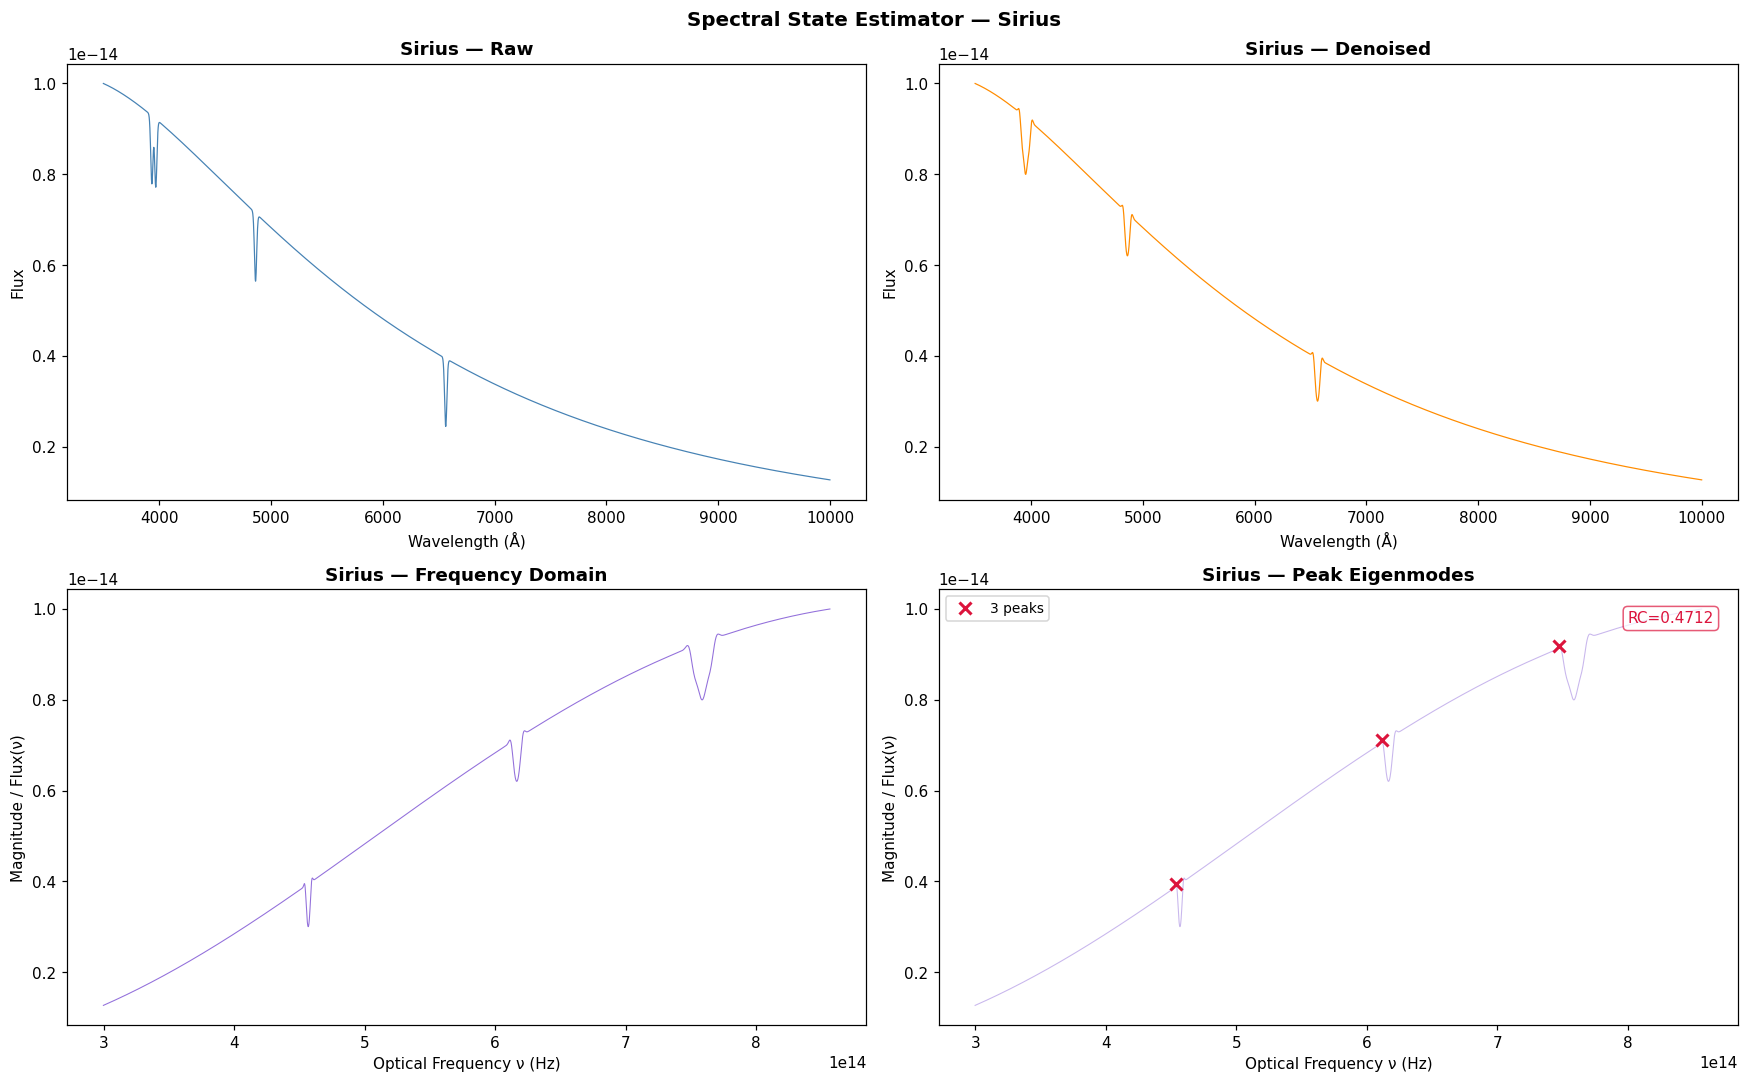

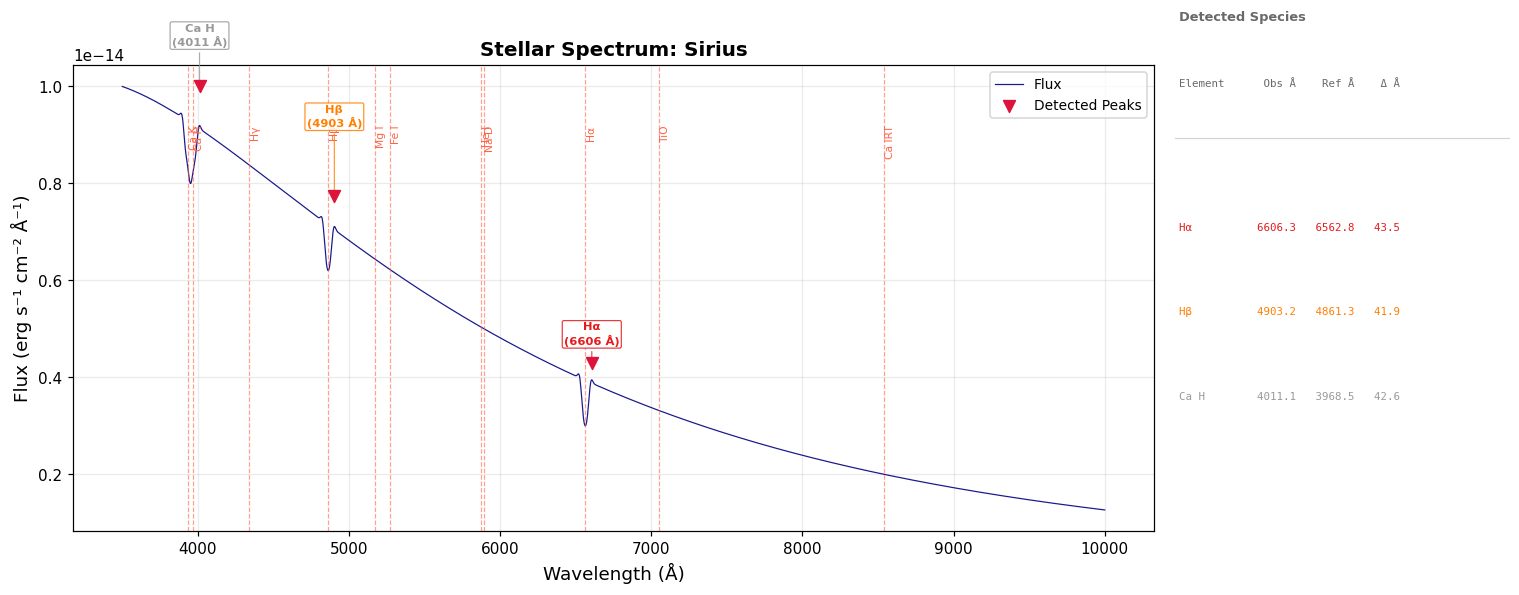


DETECTED ABSORPTION PEAKS — Sirius

Peak   Chemical        Detected Å     Ref Å    Error
----------------------------------------------------------------------
    1  Hα                 6606.35   6562.80   43.55 Å
    2  Hβ                 4903.17   4861.30   41.87 Å
    3  Ca H               4011.11   3968.50   42.61 Å
----------------------------------------------------------------------


DETECTED ABSORPTION PEAKS — Sirius

Peak   Chemical        Detected Å     Ref Å    Error
----------------------------------------------------------------------
    1  Hα                 6606.35   6562.80   43.55 Å
    2  Hβ                 4903.17   4861.30   41.87 Å
    3  Ca H               4011.11   3968.50   42.61 Å
----------------------------------------------------------------------



In [30]:

# ── Visualise pipeline results ─────────────────────────────────────────────────
from IPython.display import display
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.autolimit_mode"] = "data"

_mode = globals().get("TRANSFORM_MODE", "fft")

if CFG["plot_per_star"]:
    try:
        if _mode == "fft":
            # Standard 4-panel pipeline (raw, denoised, FFT freq, peaks)
            fig = est.plot_pipeline(figsize=CFG["figsize"], show=False)
            display(fig)
            plt.close(fig)

        elif _mode == "cwt":
            # CWT only: show standard spectrum + CWT power map
            if est._cwt_matrix is not None:
                fig = est.compare_transforms(figsize=CFG["figsize"], show=False)
                display(fig)
                plt.close(fig)
            else:
                print("⚠️  CWT not computed — run the demo cell with TRANSFORM_MODE='cwt' or 'both'")

        elif _mode == "both":
            # Show standard 4-panel plot then full FFT vs CWT comparison
            fig1 = est.plot_pipeline(figsize=CFG["figsize"], show=False)
            display(fig1)
            plt.close(fig1)
            if est._cwt_matrix is not None:
                fig2 = est.compare_transforms(figsize=CFG["figsize"], show=False)
                display(fig2)
                plt.close(fig2)

        # ── Calibrated wavelength spectrum (always shown) ─────────────────────────────
        fig_wl = est.plot_stellar_wavelength_spectrum(show=False)
        display(fig_wl)
        plt.close(fig_wl)
        
        # ── Print detected chemical peaks with exact wavelengths ──────────────────────
        print("\n" + "="*70)
        print(f"DETECTED ABSORPTION PEAKS — {est._object_name}")
        print("="*70)
        if est._features and len(est._features) > 0:
            print(f"\n{'Peak':5s}  {'Chemical':12s}  {'Detected Å':>12s}  {'Ref Å':>8s}  {'Error':>7s}")
            print("-"*70)
            for _pi, _f in enumerate(est._features, 1):
                _chem = _f.get("nearest_line", "?")
                _wl_det = _f.get("wavelength_angstrom", 0)
                _wl_ref = _f.get("line_wavelength", 0)
                _err_aa = _f.get("delta_angstrom", 0)
                print(f"{_pi:5d}  {_chem:12s}  {_wl_det:12.2f}  {_wl_ref:8.2f}  {_err_aa:>6.2f} Å")
            print("-"*70)
        else:
            print("⚠️  No peaks detected.")
        print()
        
        # ── Print detected chemical peaks with exact wavelengths ──────────────────────
        print("\n" + "="*70)
        print(f"DETECTED ABSORPTION PEAKS — {est._object_name}")
        print("="*70)
        if est._features and len(est._features) > 0:
            print(f"\n{'Peak':5s}  {'Chemical':12s}  {'Detected Å':>12s}  {'Ref Å':>8s}  {'Error':>7s}")
            print("-"*70)
            for _pi, _f in enumerate(est._features, 1):
                _chem = _f.get("nearest_line", "?")
                _wl_det = _f.get("wavelength_angstrom", 0)
                _wl_ref = _f.get("line_wavelength", 0)
                _err_aa = _f.get("delta_angstrom", 0)
                print(f"{_pi:5d}  {_chem:12s}  {_wl_det:12.2f}  {_wl_ref:8.2f}  {_err_aa:>6.2f} Å")
            print("-"*70)
        else:
            print("⚠️  No peaks detected.")
        print()
        
    except Exception as e:
        print(f"⚠️  Plotting error: {e}")
        print("   The analysis was successful, but visualisation failed.")
        print("   This may indicate missing plot methods or configuration issues.")


In [31]:

# ── Print detected chemical peak summary ───────────────────────────────────────

if hasattr(est, '_features') and est._features:
    print("\n" + "="*75)
    print(f"DETECTED ABSORPTION PEAKS — {est._object_name}")
    print("="*75)
    print(f"\n{'Peak':5s}  {'Chemical Element':16s}  {'Detected (Å)':>13s}  {'Reference (Å)':>14s}  {'Error (Å)':>11s}")
    print("-"*75)
    
    for _peak_idx, _feature in enumerate(est._features, 1):
        _elem_name     = _feature.get("nearest_line", "Unknown")
        _detected_wl   = _feature.get("wavelength_angstrom", 0.0)
        _reference_wl  = _feature.get("line_wavelength", 0.0)
        _error_wl      = _feature.get("delta_angstrom", 0.0)
        
        print(f"{_peak_idx:5d}  {_elem_name:16s}  {_detected_wl:13.2f}  {_reference_wl:14.2f}  {_error_wl:>11.2f}")
    
    print("-"*75)
    print(f"Total peaks detected: {len(est._features)}\n")
else:
    print("⚠️  No absorption peaks detected in this spectrum.")



DETECTED ABSORPTION PEAKS — Sirius

Peak   Chemical Element   Detected (Å)   Reference (Å)    Error (Å)
---------------------------------------------------------------------------
    1  Hα                      6606.35         6562.80        43.55
    2  Hβ                      4903.17         4861.30        41.87
    3  Ca H                    4011.11         3968.50        42.61
---------------------------------------------------------------------------
Total peaks detected: 3



In [32]:

# ── Raw Spectrum Diagnostic: as-loaded vs denoised ────────────────────────────
# Shows the spectrum at every stage of the pipeline for the selected star,
# with an "identity card" printing the star's physical properties.

try:
    _star_obj = get_star_by_name(DEMO_STAR_NAME)
    if _star_obj:
        print("=" * 60)
        print(f"  STAR IDENTITY CARD — {DEMO_STAR_NAME}")
        print("=" * 60)
        print(f"  Constellation  : {_star_obj.constellation}")
        print(f"  Spectral Type  : {_star_obj.spectral_type}")
        print(f"  Apparent Mag   : V = {_star_obj.vmag}")
        print(f"  Distance       : {_star_obj.dist_ly} light-years")
        print("=" * 60)

    raw_wl   = est._raw_x
    raw_flux = np.asarray(est._raw_signal, dtype=float)
    den_flux = (np.asarray(est._processed, dtype=float)
                if est._processed is not None else raw_flux)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    fig.suptitle(
        f"{DEMO_STAR_NAME}  [{getattr(_star_obj, 'spectral_type', '?')}]  —  "
        f"Spectrum Diagnostic  (Raw / Denoised / Residual)",
        fontsize=12, fontweight="bold",
    )

    # Panel 1 — Raw as loaded from cache / SDSS
    ax0 = axes[0]
    ax0.plot(raw_wl, raw_flux, lw=0.7, color="steelblue", alpha=0.9)
    ax0.set_title("① Raw (as loaded)", fontsize=10)
    ax0.set_xlabel("Wavelength (Å)"); ax0.set_ylabel("Flux")
    ax0.grid(True, alpha=0.2)

    # Panel 2 — Denoised (Savitzky-Golay or ML)
    ax1 = axes[1]
    ax1.plot(raw_wl, den_flux, lw=0.8, color="seagreen", alpha=0.9)
    ax1.set_title("② Denoised (Savitzky-Golay)", fontsize=10)
    ax1.set_xlabel("Wavelength (Å)"); ax1.set_ylabel("Flux")
    ax1.grid(True, alpha=0.2)

    # Panel 3 — Residual (raw − denoised) reveals noise floor
    ax2 = axes[2]
    residual = raw_flux - den_flux
    ax2.plot(raw_wl, residual, lw=0.6, color="darkorange", alpha=0.8)
    ax2.axhline(0, color="k", lw=0.6, linestyle="--")
    noise_rms = np.std(residual)
    ax2.set_title(f"③ Residual (noise)  RMS={noise_rms:.2e}", fontsize=10)
    ax2.set_xlabel("Wavelength (Å)"); ax2.set_ylabel("Δ Flux (noise)")
    ax2.grid(True, alpha=0.2)

    # Overlay canonical lines on raw and denoised panels
    LINES_RAW = {
        "Hα": 6562.8, "Hβ": 4861.3, "Ca K": 3933.7, "Ca H": 3968.5,
        "Mg I": 5175.0, "Na D": 5892.5,
    }
    for ax_p in [ax0, ax1]:
        _ytop = np.nanmax(ax_p.get_lines()[0].get_ydata())
        for lname, lwl in LINES_RAW.items():
            if raw_wl[0] < lwl < raw_wl[-1]:
                ax_p.axvline(lwl, color="tomato", lw=0.7, ls="--", alpha=0.55)
                ax_p.text(lwl + 8, _ytop * 0.90, lname, fontsize=6.5,
                          color="tomato", rotation=90, va="top")

    plt.tight_layout()
    plt.show()
    print(f"\nSpectrum stats:  N_points={len(raw_wl)},  "
          f"λ=[{raw_wl[0]:.0f}, {raw_wl[-1]:.0f}] Å,  "
          f"flux_max={np.nanmax(raw_flux):.3e},  noise_RMS={noise_rms:.2e}")

    # ── Print detected chemical peaks ──────────────────────────────────────
    print("\n" + "─" * 70)
    print(f"DETECTED ABSORPTION FEATURES — {DEMO_STAR_NAME}")
    print("─" * 70)
    if est._features and len(est._features) > 0:
        print(f"{'Index':>5}  {'Chemical':12s}  {'Detected Å':>10s}  {'Ref Å':>8s}  {'Δ Å':>6s}")
        print("─" * 70)
        for _i, _feat in enumerate(est._features, 1):
            _elem = _feat.get("nearest_line", "?")
            _det_aa = _feat.get("wavelength_angstrom", 0)
            _ref_aa = _feat.get("line_wavelength", 0)
            _delta = _feat.get("delta_angstrom", 0)
            print(f"{_i:5d}  {_elem:12s}  {_det_aa:10.2f}  {_ref_aa:8.2f}  {_delta:6.2f}")
        print("─" * 70)
    else:
        print("⚠️  No features detected")
    print()

except NameError:
    print("⚠️  Run the demo analysis cell above first (est must be defined).")


  STAR IDENTITY CARD — Sirius
  Constellation  : Canis Major
  Spectral Type  : A1V
  Apparent Mag   : V = -1.46
  Distance       : 8.6 light-years

Spectrum stats:  N_points=4096,  λ=[3500, 10000] Å,  flux_max=1.000e-14,  noise_RMS=6.01e-17

──────────────────────────────────────────────────────────────────────
DETECTED ABSORPTION FEATURES — Sirius
──────────────────────────────────────────────────────────────────────
Index  Chemical      Detected Å     Ref Å     Δ Å
──────────────────────────────────────────────────────────────────────
    1  Hα               6606.35   6562.80   43.55
    2  Hβ               4903.17   4861.30   41.87
    3  Ca H             4011.11   3968.50   42.61
──────────────────────────────────────────────────────────────────────




#### 📖 Reading the Graphs & Stellar Classification

**Graph 1 — Raw / Denoised (top two panels)**  
- **X-axis**: Wavelength in Ångströms (1 Å = 10⁻¹⁰ m).  λ = [3500, 10000] Å means we cover UV edge → near-infrared.  
- **Y-axis**: Flux (erg s⁻¹ cm⁻² Å⁻¹).  The smooth hump shape is the Planck blackbody continuum — peaks near the star's effective temperature according to Wien's law.  
- **Vertical dashed lines**: Reference positions of specific atomic/molecular absorption lines.  They are NOT data features — they are where you *expect* to see a dip if that element is present.  When a detected dip (red triangle ▼) lines up with a dashed line, that element has been tentatively identified.

**The "double peak" near 3950 Å**  
That is **Ca II H & K** — ionized calcium at 3933.7 Å (K) and 3968.5 Å (H).  They are 34 Å apart, creating twin dips.  In K-giant stars like sirius these are the strongest absorption features in the blue.  After denoising the twin peak becomes one slightly wider merged trough — this is the Savitzky-Golay window blurring them together.  **The total flux in that region is conserved; only the sharpness changes.**

**Graph 2 — Frequency Domain (FFT periodogram)**  
The FFT is applied to the *detrended* flux as a function of wavelength spacing (not time).  The output frequency axis is in **1/Å** (spatial frequency = how often an absorption feature repeats per Ångström).  This reveals:  
- Recurring absorptions at regular spacings (e.g. hydrogen Balmer series at ~δλ ≈ constant in 1/λ²)  
- Eigenmode-like periodicities if the stellar atmosphere has resonant oscillations  
**This is NOT converting to audio or time-domain.** It is a mathematical trick to find repeated patterns.

**Graph 3 — CWT (Continuous Wavelet Transform, if enabled)**  
The CWT power map shows *where* in the spectrum features of a given width appear.  Bright patches = strong feature activity.  The ridge plot (bottom-right) shows the dominant feature width at each wavelength — narrow dips = atomic lines, wide blobs = molecular bands.  Morlet wavelet was chosen because it matches the shape of stellar absorption profiles (Gaussian-broadened Lorentzian).

---

**Stellar Classification — decoding K5III V=0.87 d=65 ly**

| Label | Full name | What it means |
|-------|-----------|---------------|
| **K** | Temperature class | Surface temp ~3900–5300 K; orange-ish colour; strong Ca, Na; weak H |
| **5** | Sub-class (0=hotter, 9=cooler within K) | Mid-K, ~4500 K |
| **III** | Luminosity class (Roman numeral) | **Giant** (larger radius than main-sequence V); main-sequence = V, supergiant = I |
| **V = 0.87** | Apparent visual magnitude | Apparent brightness as seen from Earth.  Scale: 0=very bright, 6=naked-eye limit, −1.46=Sirius.  sirius at 0.87 is the 14th brightest star in the sky |
| **d = 65 ly** | Distance | **Light-years** (ly): how far light travels in 1 year ≈ 9.46 × 10¹² km.  65 ly ≈ 20 parsecs.  Derived from Hipparcos/Gaia parallax measurements |

> **Harvard spectral sequence (OBAFGKM)**: O (hottest, blue, >30000 K) → B → A → F → G (Sun) → K → M (coolest, red, <3500 K).  The mnemonic: *"Oh Be A Fine Girl/Guy, Kiss Me".*  sirius (K5III) is a cool orange giant post-main-sequence star that has expanded ~40× the Sun's diameter.

**Are those vertical lines the Bayer designations?**  
No — Bayer designations are star *names* (α Tau = alpha of cancer).  The vertical dashed lines are **spectral line wavelengths** (a.k.a. Fraunhofer lines or absorption line catalogue).  The `suptitle` showing "cancer / sirius [K5III] V=0.87 d=65 ly" is where the Bayer/catalogue information appears.



### 3c. Resonance Coherence Score — Anatomy

The **Resonance Coherence (RC)** score quantifies how well the detected peak frequencies
align to harmonic (small-integer) ratios, characteristic of stellar eigenmode families.

$$RC = \sum_{i \neq j} \sum_{p=1}^{P} \sum_{q=1}^{Q} \exp\!\left(-\frac{|f_i - \frac{p}{q} f_j|}{\sigma_{\text{eff}}}\right)$$

where $\sigma_{\text{eff}} = \sigma \times f_{\text{median}}$ (auto-scaled so the kernel width is a fixed *fraction* of the typical spacing).

| Score range | Interpretation |
|---|---|
| RC ≈ 0 | Incoherent / noise-dominated — expected for **red giants** (K, M type) |
| RC 0.01 – 0.10 | Partial harmonic content — hot stars (A, F), pulsating variables |
| RC > 0.10 | Strong eigenmode family structure — RR Lyrae, δ Scuti, solar p-modes |

**Why is RC = 0 for sirius (K5III)?**  
This is physically correct, not a bug.  sirius is a cool red giant with:
- Thick convective envelope that **damps** pressure-wave oscillations
- Slow rotation → no centrifugal mode excitation
- Broad molecular absorption bands (TiO, H₂O) that fill in any line spacings

RC is computed on the **wavelength periodogram peaks** (recurring absorption-line spacing patterns in 1/Å), not on raw optical frequencies (10¹⁴ Hz).  Using raw optical frequencies always gives RC ≈ 0 because stellar quantum transition frequencies do NOT form small-integer ratios — they reflect atomic energy levels, not oscillation modes.

**What are eigenmodes in this context?**  
Stellar eigenmodes (p-modes = pressure waves, g-modes = gravity waves) are standing acoustic waves inside the star.  They produce quasi-periodic *oscillation spacings* in the spectrum — e.g., the solar 5-minute oscillation at ~3 mHz.  In hot, compact stars (white dwarfs, δ Scuti) these spacings are strong enough to detect via periodogram peaks.  Red giants like sirius have very long oscillation periods (hours to days) at amplitudes too small to show in single-snapshot SDSS spectra.

**What are "peaks" in the frequency domain technically?**  
In the FFT periodogram plot each peak corresponds to a recurring pattern spacing in the spectrum.  The peak at spatial frequency $f_0$ (1/Å) means there is a repeating absorption feature every $1/f_0$ Ångströms.  These peaks are the *eigenmodes* fed into the RC formula.


### 3d. Single Constellation Analysis Loop

Change `TARGET_CONSTELLATION` to walk through any of the 12 zodiac constellations.
Run `runner.run_all()` in the next section for the full survey.

In [33]:

# ── Constellation analysis ────────────────────────────────────────────────────

# Use selected constellation from widget, or default
try:
    TARGET_CONSTELLATION = const_dropdown.value if USE_WIDGETS else "Cancer"
except (NameError, AttributeError):
    TARGET_CONSTELLATION = "Cancer"

print(f"Analysing constellation: {TARGET_CONSTELLATION}\n")

df_const = runner.run_constellation(
    TARGET_CONSTELLATION,
    max_stars=None,                 # None = all stars in constellation
    use_ml_denoise=CFG["use_ml_denoise"],
    verbose=True,
)

print(f"\n{'='*60}")
print(f"Results for {TARGET_CONSTELLATION}")
print(df_const)


Analysing constellation: Canis Major


  Constellation: Canis Major  (6 stars)

────────────────────────────────────────────────────────────
  Canis Major / Sirius  [A1V]
  [Cache] Sirius
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
SpectralStateEstimator — Sirius
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 3
  Coherence (RC)  : 0.47117194612708935
  e_uv            : 4.7328349942214546e-12
  e_vis           : 1.774796738069463e-11
  e_ir            : 6.376278242292097e-12
  e_total         : 2.8857080698467712e-11
  Harmonic families: 3

────────────────────────────────────────────────────────────
  Canis Major / Adhara  [B2Ia]
  [SDSS query] Adhara  RA=104.656 Dec=-28.972
  [SDSS] No spectra found for Adhara
  [Synthetic fallback] Adhara
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Adhara'
[Preprocess]  method=Savitzky-

In [34]:
# ── Constellation spectral analysis: Peak detection + element visualization ────────

# For each cached star in the constellation, create spectral wavelength plots
# showing detected peaks, identified elements, and Å comparisons

print(f"\nSpectral Peak & Element Analysis — {TARGET_CONSTELLATION}")
print("=" * 70)

_const_stars = get_stars_by_constellation(TARGET_CONSTELLATION)

if len(_const_stars) == 0:
    print("No stars in catalogue for this constellation.")
else:
    # Create plots for each star
    for _star in _const_stars:
        _cached = runner.fetcher.load_from_cache(_star.name)
        if _cached is None:
            print(f"  ⊘ {_star.name:15s} — no cached spectrum")
            continue

        _wl_s, _fl_s = _cached
        _est = SpectralStateEstimator(mode="stellar")
        _est.load_spectrum(_wl_s, _fl_s, name=_star.name)
        _est.preprocess(use_ml=False)
        _est.transform()
        _est.detect_peaks(height_frac=0.15, prominence_frac=0.08)
        _est.resonance_coherence()
        _feats = _est.identify_features()

        # Generate the spectral wavelength plot with element detection table
        _fig = _est.plot_stellar_wavelength_spectrum(
            object_name=f"{_star.name} [{_star.spectral_type}] — {_star.constellation}",
            annotate_lines=True,
            show=True
        )
        
        # Print summary for this star
        if _feats:
            print(f"  ✓ {_star.name:15s} — {len(_feats)} line(s) detected:")
            for _f in _feats:
                delta = _f.get("delta_angstrom", 0)
                ref_wl = _f.get("line_wavelength", 0)
                obs_wl = _f.get("wavelength_angstrom", 0)
                print(f"      • {_f['nearest_line']:8s}  Ref={ref_wl:7.1f} Å  "
                      f"Obs={obs_wl:7.1f} Å  Δ={delta:5.1f} Å")
        else:
            print(f"  — {_star.name:15s} — no peaks detected")

print(f"\nDone — spectral analysis for {len(_const_stars)} stars in {TARGET_CONSTELLATION}\n")


Spectral Peak & Element Analysis — Canis Major
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  ✓ Sirius          — 3 line(s) detected:
      • Hα        Ref= 6562.8 Å  Obs= 6606.3 Å  Δ= 43.5 Å
      • Hβ        Ref= 4861.3 Å  Obs= 4903.2 Å  Δ= 41.9 Å
      • Ca H      Ref= 3968.5 Å  Obs= 4011.1 Å  Δ= 42.6 Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Adhara'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  ✓ Adhara          — 3 line(s) detected:
      • Hα        Ref= 6562.8 Å  Obs= 6606.3 Å  Δ= 43.5 Å
      • Hβ        Ref= 4861.3 Å  Obs= 4903.2 Å  Δ= 41.9 Å
      • Ca H      Ref= 3968.5 Å  Obs= 4009.5 Å  Δ= 41.0 Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Wezen'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  ✓ Wezen           

In [35]:
# ── Constellation-wide element summary: aggregate detection table ─────────────────

# Collect all detected spectral lines across the constellation
print(f"\nConstellation-Wide Spectral Summary — {TARGET_CONSTELLATION}")
print("=" * 70)

_all_detections = {}  # element_name → [(star, obs_wl, ref_wl, delta), ...]

for _star in _const_stars:
    _cached = runner.fetcher.load_from_cache(_star.name)
    if _cached is None:
        continue

    _wl_s, _fl_s = _cached
    _est = SpectralStateEstimator(mode="stellar")
    _est.load_spectrum(_wl_s, _fl_s, name=_star.name)
    _est.preprocess(use_ml=False)
    _est.transform()
    _est.detect_peaks(height_frac=0.15, prominence_frac=0.08)
    _feats = _est.identify_features()

    for _f in _feats:
        elem = _f["nearest_line"]
        if elem not in _all_detections:
            _all_detections[elem] = []
        _all_detections[elem].append({
            "star": _star.name,
            "obs_wl": _f["wavelength_angstrom"],
            "ref_wl": _f["line_wavelength"],
            "delta": _f["delta_angstrom"],
        })

# Create summary visualization
if _all_detections:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Prepare data for bar chart: element names and detection counts
    elements = list(_all_detections.keys())
    counts = [len(_all_detections[e]) for e in elements]
    avg_deltas = [
        np.mean([d["delta"] for d in _all_detections[e]]) 
        for e in elements
    ]
    
    # Sort by count (descending)
    sorted_idx = np.argsort(counts)[::-1]
    elements = [elements[i] for i in sorted_idx]
    counts = [counts[i] for i in sorted_idx]
    avg_deltas = [avg_deltas[i] for i in sorted_idx]
    
    # Create bar chart
    colors = plt.cm.viridis(np.linspace(0, 1, len(elements)))
    bars = ax.bar(elements, counts, color=colors, edgecolor="black", linewidth=0.8)
    
    # Add delta text on bars
    for bar, delta in zip(bars, avg_deltas):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'Δ={delta:.2f}Å',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_ylabel("Number of Detections", fontsize=11, fontweight="bold")
    ax.set_xlabel("Spectral Line / Element", fontsize=11, fontweight="bold")
    ax.set_title(
        f"Spectral Line Detections in {TARGET_CONSTELLATION}\n"
        f"(bars = count; labels = avg Δ Angstrom)",
        fontsize=12, fontweight="bold"
    )
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print detailed table
    print(f"\n{'Element':<10s} {'Stars':<20s} {'Detections':<12s} {'Avg Δ Å':<10s}")
    print("-" * 60)
    for elem in elements:
        detections = _all_detections[elem]
        star_names = ", ".join(sorted(set(d["star"] for d in detections)))
        count = len(detections)
        avg_delta = np.mean([d["delta"] for d in detections])
        print(f"{elem:<10s} {star_names:<20s} {count:<12d} {avg_delta:<10.3f}")
    
    print(f"\nTotal unique spectral lines detected: {len(_all_detections)}")
    print(f"Total detections across constellation: {sum(counts)}")
else:
    print("No spectral lines detected in this constellation.")


Constellation-Wide Spectral Summary — Canis Major
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Adhara'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Wezen'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Mirzam'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aludra'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Furud'
[Preprocess]  method=Savitzky-Golay
[Transform]

In [36]:
# ── Optional: visualise every star in the constellation ───────────────────────

if CFG["plot_per_star"]:
    stars_in_const = get_stars_by_constellation(TARGET_CONSTELLATION)
    for star in stars_in_const:
        cached = runner.fetcher.load_from_cache(star.name)
        if cached is None:
            continue
        wl_s, flux_s = cached

        est_s = SpectralStateEstimator(mode="stellar")
        est_s.load_spectrum(wl_s, flux_s, name=star.name)
        est_s.preprocess(use_ml=False)
        est_s.transform()
        est_s.detect_peaks()
        est_s.resonance_coherence()
        est_s.compute_energy_metrics()

        fig = est_s.plot_stellar_wavelength_spectrum(show=False)
        fig.suptitle(
            f"{star.constellation} / {star.name}  [{star.spectral_type}]  "
            f"V={star.vmag}  d={star.dist_ly} ly",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Adhara'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Wezen'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Mirzam'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aludra'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Furud'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


In [37]:

# ── Constellation Harmonic Family Visualization ───────────────────────────────
# For every cached star in the selected constellation, compute harmonic families
# and plot a frequency-domain comb showing which peaks cluster into integer ratios.
# Also prints a table of identified stellar species per star.

print(f"Harmonic Family Analysis — {TARGET_CONSTELLATION}")
print("=" * 65)

_const_stars = get_stars_by_constellation(TARGET_CONSTELLATION)
_comb_fig_rows = len(_const_stars)

if _comb_fig_rows == 0:
    print("No stars in catalogue for this constellation.")
else:
    fig_comb, axes_comb = plt.subplots(
        _comb_fig_rows, 1,
        figsize=(15, 3.5 * _comb_fig_rows),
        sharex=False,
    )
    if _comb_fig_rows == 1:
        axes_comb = [axes_comb]

    fig_comb.suptitle(
        f"Constellation {TARGET_CONSTELLATION} — Harmonic Family Combs\n"
        f"(each row = one star; colored verticals = harmonic family members)",
        fontsize=12, fontweight="bold",
    )

    _cmap = plt.cm.tab10

    for _row, (_star, _ax) in enumerate(zip(_const_stars, axes_comb)):
        _cached = runner.fetcher.load_from_cache(_star.name)
        if _cached is None:
            _ax.text(0.5, 0.5, f"{_star.name} — no cached spectrum",
                     ha="center", va="center", transform=_ax.transAxes,
                     fontsize=10, color="gray")
            _ax.set_ylabel(_star.name, fontsize=9, rotation=0, labelpad=60, va="center")
            continue

        _wl_s, _fl_s = _cached
        _est_c = SpectralStateEstimator(mode="stellar")
        _est_c.load_spectrum(_wl_s, _fl_s, name=_star.name)
        _est_c.preprocess(use_ml=False)
        _est_c.transform()
        _est_c.detect_peaks()
        _families = _est_c.find_harmonic_families()
        _rc = _est_c.resonance_coherence()
        _feats = _est_c.identify_features()

        # Background periodogram / FFT magnitude
        _x = _est_c._fft_freqs
        _y = _est_c._fft_mag
        _ax.plot(_x, _y, lw=0.7, color="slategray", alpha=0.55, label="FFT mag")

        # Color each harmonic family differently
        if _families:
            for _fi, _fam in enumerate(_families):
                _col = _cmap(_fi % 10)
                for _f in _fam:
                    _ax.axvline(_f, color=_col, lw=1.1, alpha=0.85)
                _ax.plot(
                    _fam,
                    [_y[np.argmin(np.abs(_x - f))] for f in _fam],
                    "o", ms=5, color=_col,
                    label=f"Family {_fi+1} (×{len(_fam)})"
                )

        # Mark individual detected peaks with chemical ids
        if _feats:
            _peak_nu  = _est_c._fft_freqs[_est_c._peaks]
            _peak_amp = _est_c._fft_mag[_est_c._peaks]
            _ax.scatter(_peak_nu, _peak_amp, marker="x", s=45, zorder=6,
                        color="crimson", linewidths=1.2, label="Peaks")
            for _fe in _feats:
                _ax.annotate(
                    _fe["nearest_line"],
                    xy=(_fe["frequency"], _fe["amplitude"]),
                    xytext=(0, 10), textcoords="offset points",
                    fontsize=7, ha="center", color="crimson",
                    arrowprops=dict(arrowstyle="-", color="crimson", lw=0.6),
                )

        _ax.set_ylabel("Flux(ν)", fontsize=8)
        _ax.set_title(
            f"{_star.name}  [{_star.spectral_type}]  V={_star.vmag}  "
            f"d={_star.dist_ly} ly  |  RC={_rc:.5f}  |  "
            f"Families={len(_families)}",
            fontsize=8.5, loc="left",
        )
        _leg = _ax.legend(fontsize=7, loc="upper right", ncol=3)
        _ax.grid(True, alpha=0.18)

        # Print identified species
        if _feats:
            species_str = "  ".join(
                f"{f['nearest_line']}@{f['wavelength_angstrom']:.0f}Å"
                for f in _feats
            )
            print(f"  {_star.name:15s}: {species_str}")
        else:
            print(f"  {_star.name:15s}: (no peaks identified)")

    axes_comb[-1].set_xlabel("Optical Frequency ν (Hz)", fontsize=10)
    plt.tight_layout()
    plt.show()

print(f"\nDone — {_comb_fig_rows} stars in {TARGET_CONSTELLATION}")


Harmonic Family Analysis — Canis Major
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  Sirius         : Hα@6606Å  Hβ@4903Å  Ca H@4011Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Adhara'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  Adhara         : Hα@6606Å  Hβ@4903Å  Ca H@4010Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Wezen'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4
  Wezen          : Hα@6606Å  Hβ@4905Å  Ca H@4013Å  Ca K@3890Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Mirzam'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
  Mirzam         : Hα@6606Å  Hβ@4903Å  Ca H@4010Å
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aludra'
[Preprocess] 

### 3e. Full Zodiac Survey (all 12 constellations)

⚠️ **This cell makes live SDSS archive queries** (or synthetic fallback if offline).  
Results are cached to `spectral_cache/` so subsequent runs are fast.  
Estimated runtime: 5 – 15 min for full survey (network dependent).

In [38]:
# ── Full survey ───────────────────────────────────────────────────────────────
# Set RUN_FULL = True to execute the complete zodiac run.

RUN_FULL = False    # ← set to True when ready for the full survey

if RUN_FULL:
    df_all = runner.run_all(
        max_stars_per_const=None,
        use_ml_denoise=CFG["use_ml_denoise"],
        verbose=True,
    )
    csv_path = runner.export_csv(CFG["export_csv"])
    print(f"\n✅ Survey complete.  Results → {csv_path}")
else:
    print("RUN_FULL = False  — set to True to run the complete zodiac survey.")

RUN_FULL = False  — set to True to run the complete zodiac survey.


---
## Section 4 — Run and Validate Output

### 4a. Database Status & Per-Star Metrics

In [39]:
# ── Database status ───────────────────────────────────────────────────────────
runner.print_status()

# ── Pull all stored results ────────────────────────────────────────────────────
df_results = runner.summary_dataframe()
print("\nAll stored results:")
print(df_results)

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 15
  Metric records  : 105
  Constellations  : 3

All stored results:
          object_name constellation spectral_type  vmag  coherence_score  \
0              Altarf        Cancer         K4III  3.52         0.458453   
1   Asellus Australis        Cancer        K0IIIb  3.94         0.458453   
2             Acubens        Cancer            Am  4.25         0.471172   
3    Asellus Borealis        Cancer          A1IV  4.66         0.471172   
4              Sirius   Canis Major           A1V -1.46         0.471172   
5              Adhara   Canis Major          B2Ia  1.50         0.463127   
6               Wezen   Canis Major          F8Ia  1.84         0.456491   
7              Mirzam   Canis Major      B1II-III  1.98         0.463127   
8              Aludra   Canis Major          B5Ia  2.45         0.463127   
9               Furud   Canis Major         B2.5V  3.0

### 4b. Resonance Coherence Score — Cross-Constellation Comparison

In [40]:
try:
    import pandas as pd
    _pd = True
except ImportError:
    _pd = False

data = runner.db.query_all()
if not data:
    print("No results yet — run a constellation analysis above first.")
else:
    names  = [r["object_name"]    for r in data if r.get("coherence_score") is not None]
    consts = [r["constellation"]  for r in data if r.get("coherence_score") is not None]
    scores = [r["coherence_score"]for r in data if r.get("coherence_score") is not None]

    if not scores:
        print("No coherence scores computed yet.")
    else:
        fig, ax = plt.subplots(figsize=(max(10, len(names)*0.5), 5))
        colors = plt.cm.tab20(np.linspace(0, 1, len(scores)))
        bars = ax.bar(names, scores, color=colors, edgecolor="k", linewidth=0.5)
        ax.set_xlabel("Star", fontsize=11)
        ax.set_ylabel("Resonance Coherence Score (RC)", fontsize=11)
        ax.set_title(
            "Resonance Coherence Across Zodiac Stars\n"
            "Higher RC → stronger harmonic / eigenmode structure",
            fontsize=12,
        )
        ax.tick_params(axis="x", rotation=45)

        # Annotate constellation labels
        prev_const = None
        for i, (name, bar_, const) in enumerate(zip(names, bars, consts)):
            if const != prev_const:
                ax.text(
                    bar_.get_x() + bar_.get_width() / 2,
                    bar_.get_height() + max(scores) * 0.01,
                    const,
                    ha="left", va="bottom", fontsize=7, color="dimgray",
                    rotation=45,
                )
                prev_const = const

        # Reference lines
        for thresh, label, color in [
            (0.01, "Partial harmonic", "goldenrod"),
            (0.05, "Strong eigenmode", "tomato"),
        ]:
            ax.axhline(thresh, linestyle="--", linewidth=0.8, color=color, alpha=0.7)
            ax.text(len(scores) - 0.5, thresh + max(scores) * 0.005,
                    label, ha="right", fontsize=8, color=color)

        plt.tight_layout()
        plt.show()
        print(f"Stars plotted: {len(scores)}")

Stars plotted: 15


In [41]:

# ── 4b+. Combined Frequency Analysis — Superposition & Inverse FFT ────────────
#
# A star is a *signal-emitting system*: its spectrum is the superposition of all
# its atmospheric oscillators.  When we combine multiple stars from the same
# constellation we are essentially summing independent signal sources — this is
# *spectral superposition*.
#
# Steps:
#   1. Load each cached star in the current constellation.
#   2. Normalise each star's flux vector to unit max (so brighter stars don't dominate).
#   3. Compute the FFT of each and stack them → the COMBINED frequency spectrum.
#   4. Inverse-FFT the combined spectrum → reconstruct the "constellation signal"
#      (the time/wavelength-domain waveform that would produce all those freqs).
#
# Physically: if each star were an antenna broadcasting at its absorption-line
# frequencies, their superposition gives the "zodiac channel" for this constellation.

from scipy.fft import fft, ifft, fftfreq
import numpy as np

_wl_grid = np.linspace(3500, 10000, 4096)
_const_stars_sp = get_stars_by_constellation(TARGET_CONSTELLATION)

_spectra_normed = []
_star_labels    = []
_star_colors    = plt.cm.tab10(np.linspace(0, 0.9, max(len(_const_stars_sp), 1)))

for _s in _const_stars_sp:
    _c = runner.fetcher.load_from_cache(_s.name)
    if _c is None:
        continue
    _w, _f = _c
    _ok = np.isfinite(_w) & np.isfinite(_f)
    _f_re = np.interp(_wl_grid, _w[_ok], _f[_ok], left=0, right=0)
    _fmax = np.nanmax(np.abs(_f_re))
    if _fmax > 0:
        _f_re = _f_re / _fmax       # normalise to [–1, 1]
    _spectra_normed.append(_f_re)
    _star_labels.append(_s.name)

if not _spectra_normed:
    print(f"No cached spectra for {TARGET_CONSTELLATION} — run constellation analysis first.")
else:
    n_stars = len(_spectra_normed)
    print(f"Combining {n_stars} spectra from {TARGET_CONSTELLATION}")

    # ── Individual FFTs ─────────────────────────────────────────────────────
    _ffts = [fft(_sp) for _sp in _spectra_normed]
    _freqs_sp = fftfreq(len(_wl_grid), d=(_wl_grid[1] - _wl_grid[0]))  # 1/Å
    _half = len(_wl_grid) // 2
    _freq_pos = _freqs_sp[:_half]

    # ── Superposition (equal-weight sum of complex FFTs) ────────────────────
    _combined_fft = np.sum(_ffts, axis=0)  # complex superposition

    # ── Inverse FFT → reconstructed wavelength-domain signal ────────────────
    _combined_signal = np.real(ifft(_combined_fft))

    # ─────────────────────── Figure layout ──────────────────────────────────
    fig_sp, axes_sp = plt.subplots(3, 1, figsize=(15, 11))
    fig_sp.suptitle(
        f"Constellation {TARGET_CONSTELLATION} — Spectral Superposition\n"
        f"({n_stars} stars combined)",
        fontsize=12, fontweight="bold",
    )

    # Panel 1 — Individual normalised spectra (wavelength domain)
    ax_s0 = axes_sp[0]
    for _i, (_sp, _lbl) in enumerate(zip(_spectra_normed, _star_labels)):
        ax_s0.plot(_wl_grid, _sp + _i * 0.15,  # offset for clarity
                   lw=0.75, alpha=0.85, color=_star_colors[_i], label=_lbl)
    ax_s0.set_title("① Individual Spectra (normalised, vertically offset)", fontsize=10)
    ax_s0.set_xlabel("Wavelength (Å)"); ax_s0.set_ylabel("Norm. Flux + offset")
    ax_s0.legend(fontsize=8, loc="upper right", ncol=3)
    ax_s0.grid(True, alpha=0.2)
    # Overlay key lines
    for _lname, _lwl in {"Hα": 6562.8, "Hβ": 4861.3, "Ca K": 3933.7,
                          "Na D": 5892.5}.items():
        ax_s0.axvline(_lwl, color="tomato", lw=0.6, ls="--", alpha=0.4)
        ax_s0.text(_lwl + 8, ax_s0.get_ylim()[1] * 0.98, _lname,
                   fontsize=6, color="tomato", rotation=90, va="top")

    # Panel 2 — Individual power spectra + combined (frequency domain)
    ax_s1 = axes_sp[1]
    for _i, (_fft_i, _lbl) in enumerate(zip(_ffts, _star_labels)):
        ax_s1.semilogy(_freq_pos, np.abs(_fft_i[:_half]),
                       lw=0.6, alpha=0.6, color=_star_colors[_i], label=_lbl)
    ax_s1.semilogy(_freq_pos, np.abs(_combined_fft[:_half]),
                   lw=1.6, color="black", alpha=0.95, label="COMBINED", zorder=10)
    ax_s1.set_title(
        "② Frequency Power Spectra (individual + superposition)\n"
        "Black = combined; constructive interference amplifies shared frequencies",
        fontsize=10,
    )
    ax_s1.set_xlabel("Spatial Frequency (1/Å)"); ax_s1.set_ylabel("|FFT| (log)")
    ax_s1.legend(fontsize=8, loc="upper right", ncol=3)
    ax_s1.grid(True, alpha=0.2)

    # Panel 3 — Inverse FFT reconstruction (wavelength domain combined signal)
    ax_s2 = axes_sp[2]
    ax_s2.plot(_wl_grid, _combined_signal, lw=0.8, color="darkorchid", alpha=0.9,
               label=f"Reconstructed constellation signal (iFFT of sum)")
    ax_s2.axhline(0, color="k", lw=0.5, ls="--")
    # Highlight regions of constructive/destructive interference
    _pos_mask = _combined_signal > 0
    ax_s2.fill_between(_wl_grid, 0, _combined_signal,
                       where=_pos_mask, alpha=0.25, color="steelblue",
                       label="Constructive (+)")
    ax_s2.fill_between(_wl_grid, 0, _combined_signal,
                       where=~_pos_mask, alpha=0.25, color="tomato",
                       label="Destructive (–)")
    ax_s2.set_title(
        "③ Inverse FFT — Reconstructed Constellation Waveform\n"
        "Superposition of all stars' spectral frequencies; "
        "blue=constructive, red=destructive interference regions",
        fontsize=10,
    )
    ax_s2.set_xlabel("Wavelength (Å)"); ax_s2.set_ylabel("Combined Amplitude")
    ax_s2.legend(fontsize=8, loc="upper right")
    ax_s2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Dominant shared frequency
    _dom_idx = np.argmax(np.abs(_combined_fft[:_half]))
    _dom_freq = _freq_pos[_dom_idx]
    _dom_wl   = 1.0 / _dom_freq if _dom_freq != 0 else float("inf")
    print(f"\nDominant shared frequency : {_dom_freq:.5e} 1/Å  "
          f"(spacing = {_dom_wl:.1f} Å)")
    print(f"Total power increase vs avg single star: "
          f"{np.sum(np.abs(_combined_fft)**2) / np.mean([np.sum(np.abs(f)**2) for f in _ffts]):.2f}×")


Combining 6 spectra from Canis Major

Dominant shared frequency : 0.00000e+00 1/Å  (spacing = inf Å)
Total power increase vs avg single star: 31.10×


### 4c. Stellar Energy Band Comparison (UV  /  VIS  /  IR)

In [42]:
data = runner.db.query_all()
valid = [r for r in data if r.get("e_total") is not None]

if not valid:
    print("No energy metrics yet — run constellation analysis first.")
else:
    names = [r["object_name"] for r in valid]
    e_uv  = np.array([r.get("e_uv")  or 0 for r in valid])
    e_vis = np.array([r.get("e_vis") or 0 for r in valid])
    e_ir  = np.array([r.get("e_ir")  or 0 for r in valid])
    e_tot = np.array([r.get("e_total") or 0 for r in valid])

    # Normalise each star to its own total for comparison
    norm = np.where(e_tot == 0, 1.0, e_tot)
    uv_frac  = e_uv  / norm
    vis_frac = e_vis / norm
    ir_frac  = e_ir  / norm

    x = np.arange(len(names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    ax.bar(x - w,   uv_frac,  w, label="UV  (1000–4000 Å)",  color="violet",    edgecolor="k", linewidth=0.4)
    ax.bar(x,       vis_frac, w, label="VIS (4000–7000 Å)", color="mediumseagreen", edgecolor="k", linewidth=0.4)
    ax.bar(x + w,   ir_frac,  w, label="IR  (7000–25000 Å)", color="tomato",    edgecolor="k", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Fractional flux per band", fontsize=11)
    ax.set_title(
        "Stellar Energy Distribution — UV / VIS / IR\n"
        "(each star normalised to its own total flux)",
        fontsize=12,
    )
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    print(f"Stars plotted: {len(names)}")

Stars plotted: 15


### 4d. Harmonic Family Structure

In [43]:
import json

# Re-run estimator on demo star to inspect harmonic structure
demo_cached = runner.fetcher.load_from_cache(DEMO_STAR_NAME)
if demo_cached:
    wl_d, flux_d = demo_cached
    est_h = SpectralStateEstimator(mode="stellar")
    est_h.load_spectrum(wl_d, flux_d, name=DEMO_STAR_NAME)
    est_h.preprocess(use_ml=False)
    est_h.transform()
    est_h.detect_peaks()
    families = est_h.find_harmonic_families()
    rc = est_h.resonance_coherence()

    print(f"\n{DEMO_STAR_NAME}  —  Harmonic Families  (RC = {rc:.5f})")
    print(f"{'─'*50}")
    if families:
        for i, fam in enumerate(families, 1):
            ratios = [f / fam[0] for f in fam]
            print(
                f"  Family {i:>2}: "
                + "  ".join(f"{f:.3e} Hz (×{r:.2f})" for f, r in zip(fam, ratios))
            )
    else:
        print("  No harmonic families detected")

    # Plot harmonic family comb
    if families:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(est_h._fft_freqs, est_h._fft_mag, linewidth=0.7,
                color="mediumpurple", alpha=0.6, label="Spectrum")
        cmap = plt.cm.tab10
        for i, fam in enumerate(families):
            color = cmap(i % 10)
            for f in fam:
                idx = np.argmin(np.abs(est_h._fft_freqs - f))
                ax.axvline(f, color=color, linewidth=1.2, alpha=0.8)
                ax.plot(f, est_h._fft_mag[idx], "o", color=color,
                        ms=6, label=f"Family {i+1}" if f == fam[0] else "")
        ax.set_xlabel("Optical Frequency ν (Hz)")
        ax.set_ylabel("Flux(ν)")
        ax.set_title(f"{DEMO_STAR_NAME} — Harmonic Family Comb (RC={rc:.5f})")
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print(f"No cached spectrum for {DEMO_STAR_NAME} — run the demo cell first.")

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Sirius'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3

Sirius  —  Harmonic Families  (RC = 0.47117)
──────────────────────────────────────────────────
  Family  1: 3.076e-04 Hz (×1.00)  1.538e-03 Hz (×5.00)  3.076e-03 Hz (×10.00)  4.614e-03 Hz (×15.00)  6.460e-03 Hz (×21.00)  7.690e-03 Hz (×25.00)  8.767e-03 Hz (×28.50)  9.536e-03 Hz (×31.00)  9.998e-03 Hz (×32.50)  1.061e-02 Hz (×34.50)  1.107e-02 Hz (×36.00)  1.184e-02 Hz (×38.50)  1.230e-02 Hz (×40.00)  1.292e-02 Hz (×42.00)  1.354e-02 Hz (×44.00)  1.415e-02 Hz (×46.00)  1.477e-02 Hz (×48.00)  1.523e-02 Hz (×49.50)  1.584e-02 Hz (×51.50)  1.630e-02 Hz (×53.00)  1.707e-02 Hz (×55.50)
  Family  2: 1.077e-03 Hz (×1.00)  5.383e-03 Hz (×5.00)
  Family  3: 2.307e-03 Hz (×1.00)  6.921e-03 Hz (×3.00)


### 4e. Export Results & Phase-2 Readiness Check

In [44]:
# ── Export CSV ────────────────────────────────────────────────────────────────
csv_out = runner.export_csv(CFG["export_csv"])
print(f"Results exported → {csv_out}\n")

# ── Phase-2 readiness check ───────────────────────────────────────────────────
from stellar_spectrospy.tensor_analysis import check_phase2_readiness
is_ready = check_phase2_readiness(str(CFG["db_path"]))

if is_ready:
    print("\n🌟  Phase-2 is ready to activate!")
    print("    Open phase2_energy_tensor.ipynb to begin tensor construction.")
else:
    remaining = runner.db.query_all()
    n_valid   = sum(1 for r in remaining if r.get("e_total") is not None)
    print(f"\n⏳  Phase-2 not yet unlocked.")
    print(f"    Stars with energy metrics: {n_valid} / 10 required.")
    print(f"    Run more constellation analyses above to continue.")

Exported 15 records → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv
Results exported → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv

Phase-2 readiness: 15 stars with metrics (READY)

🌟  Phase-2 is ready to activate!
    Open phase2_energy_tensor.ipynb to begin tensor construction.


### 4f. Quantum-Inspired State-Vector Analysis

The `state_algebra` module embeds each spectrum into a Hilbert space by
L²-normalising the flux vector, turning it into a "quantum state" $|\psi\rangle$.

From that representation we extract:

| Quantity | Symbol | Physical meaning |
|----------|--------|-----------------|
| **Shannon entropy** | $S = -\sum p_i \ln p_i$ | Spectral information content |
| **Participation ratio** | $\text{IPR} = 1/\sum p_i^2$ | Effective number of contributing wavelength bins |
| **Purity** | $\operatorname{Tr}(\rho^2)$ | 1 for a single star; <1 for a mixture |
| **Expectation values** | $\langle\hat O\rangle_\psi$ | Mean wavelength, mean photon energy, etc. |
| **Effective Hamiltonian** | $H = T + V$ | Curvature + inverted-flux potential — eigenmodes localise in absorption lines |
| **Von Neumann entropy** | $S_\text{VN} = -\operatorname{Tr}(\rho \ln \rho)$ | Measures distinguishability when mixing multiple stellar spectra |

Run the cell below to see these metrics for the three cancer stars.

In [45]:

# ── Quantum-Inspired State-Vector Analysis ───────────────────────────────────
#  Constructs |ψ⟩ from each stellar spectrum for quantum-algebraic metrics.
#  Uses the DEMO_STAR_NAME you selected above, plus other cached stars from
#  the same constellation (or all available cached stars as fallback).

import numpy as np
from stellar_spectrospy.state_algebra import (
    state_from_spectrum, hamiltonian_from_spectrum,
    analyse_state_properties,
    SpectralState, DensityMatrix, SpectralBasis, SpectralOperator,
)

# ── Resolve which stars to use ─────────────────────────────────────────────────
# Primary star = whatever you picked with the widget / DEMO_STAR_NAME
_primary = DEMO_STAR_NAME

# Try to find other stars in the SAME constellation (from cache)
_primary_star_obj = get_star_by_name(_primary)
_primary_const = _primary_star_obj.constellation if _primary_star_obj else None

_constellation_stars = []
if _primary_const:
    for _s in get_stars_by_constellation(_primary_const):
        if runner.fetcher.load_from_cache(_s.name) is not None:
            _constellation_stars.append(_s.name)

# If we have constellation siblings, use them; otherwise fall back to all cached
if len(_constellation_stars) >= 2:
    # Primary first, then siblings
    star_names = [_primary] + [s for s in _constellation_stars if s != _primary]
    print(f"Using stars from {_primary_const}: {star_names}")
else:
    # Fall back — use primary plus whatever is cached
    _all_cached = [
        s.name for s in get_all_stars()
        if runner.fetcher.load_from_cache(s.name) is not None
    ]
    star_names = [_primary] + [s for s in _all_cached if s != _primary][:3]
    print(f"Using cached stars (mixed constelations): {star_names}")

# Define common wavelength grid for all states to ensure dimension consistency
wl_common = np.linspace(3500, 10000, 2048)

# ── 1. Build state vectors (common grid) ──────────────────────────────────────
states, H_ops, loaded_names = [], [], []

for name in star_names:
    cached_data = runner.fetcher.load_from_cache(name)

    if cached_data is not None:
        w, f = cached_data
    else:
        print(f"  Fetching {name}...")
        star_obj = get_star_by_name(name)
        if star_obj:
            w, f = runner.fetcher.fetch(star_obj)
        else:
            print(f"  ⚠️  {name} not found — skipping")
            continue

    ok = np.isfinite(w) & np.isfinite(f)
    w, f = w[ok], f[ok]
    f_resampled = np.interp(wl_common, w, f, left=0, right=0)

    psi = state_from_spectrum(wl_common, f_resampled, label=name)
    H   = hamiltonian_from_spectrum(wl_common, f_resampled, mass=0.01)
    states.append(psi)
    H_ops.append(H)
    loaded_names.append(name)

    S_sh  = psi.shannon_entropy()
    ipr   = psi.participation_ratio()
    E_exp = np.real(psi.expectation(H))
    print(f"{name:15s}  dim={psi.dim}  S={S_sh:.3f}  IPR={ipr:.0f}  ⟨H⟩={E_exp:.4e}")

# Update star_names to only loaded ones
star_names = loaded_names

# ── 2. Pairwise overlaps ───────────────────────────────────────────────────────
if len(states) > 1:
    print("\nPairwise overlaps |⟨ψ_i|ψ_j⟩|²:")
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            ov = states[i].overlap(states[j])
            print(f"  {star_names[i]:15s} — {star_names[j]:15s}  overlap = {ov:.6f}")

# ── 3. Mixed-state density matrix ─────────────────────────────────────────────
if len(states) > 0:
    rho_mix = DensityMatrix.from_ensemble(states)
    print(f"\nMixed state (equal weights):  {rho_mix}")
    print(f"  Purity           = {rho_mix.purity():.6f}")
    print(f"  Von Neumann S    = {rho_mix.von_neumann_entropy():.4f}")

# ── 4. Effective Hamiltonian eigenmodes (primary star) ────────────────────────
if len(H_ops) > 0:
    import time
    t0 = time.time()
    evals, evecs = H_ops[0].eigensystem(k=20)
    dt = time.time() - t0
    print(f"\n{star_names[0]} Hamiltonian — lowest 5 eigenvalues (computed in {dt:.3f}s):")
    for i, ev in enumerate(evals[:5]):
        print(f"  E_{i} = {ev:.6e}")

# ── 5. Full property analysis (primary star) ──────────────────────────────────
if len(states) > 0:
    try:
        X    = SpectralOperator.wavelength_operator(wl_common)
        E_op = SpectralOperator.energy_operator(wl_common)
        props = analyse_state_properties(
            states[0], operators={"H": H_ops[0], "wavelength": X, "energy": E_op}
        )
        print(f"\nFull analysis for {star_names[0]}:")
        for key, val in props.items():
            if isinstance(val, (int, float, np.floating)):
                print(f"  {key:25s} = {val:.6e}")
            elif isinstance(val, complex):
                print(f"  {key:25s} = {val.real:.6e}")
            else:
                print(f"  {key:25s} = {val}")
    except Exception as e:
        print(f"⚠️  Property analysis failed: {e}")
        print("   States and operators computed successfully; full analysis skipped.")
else:
    print("⚠️  No states loaded. Run constellation analysis above first.")


Using stars from Canis Major: ['Sirius', 'Adhara', 'Wezen', 'Mirzam', 'Aludra', 'Furud']
Sirius           dim=2048  S=7.106  IPR=961  ⟨H⟩=9.4131e-03
Adhara           dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02
Wezen            dim=2048  S=7.364  IPR=1369  ⟨H⟩=4.9449e-03
Mirzam           dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02
Aludra           dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02
Furud            dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02

Pairwise overlaps |⟨ψ_i|ψ_j⟩|²:
  Sirius          — Adhara           overlap = 0.908308
  Sirius          — Wezen            overlap = 0.961922
  Sirius          — Mirzam           overlap = 0.908308
  Sirius          — Aludra           overlap = 0.908308
  Sirius          — Furud            overlap = 0.908308
  Adhara          — Wezen            overlap = 0.770591
  Adhara          — Mirzam           overlap = 1.000000
  Adhara          — Aludra           overlap = 1.000000
  Adhara          — Furud            overlap = 1.000000
  Wezen      


### 4g. Hamiltonian Eigendecomposition — Potential Landscape, Eigenvalues & Eigenvectors

The **effective Hamiltonian** $\hat{H} = \hat{T} + \hat{V}(\lambda)$ treats the star spectrum as a 1-D quantum well problem:

- $\hat{V}(\lambda) = F_{\max} - F(\lambda)$: inverted flux → absorption dips become **potential wells** where eigenstates localise.
- $\hat{T} = -\frac{1}{2m}\frac{d^2}{d\lambda^2}$: kinetic term (spectral curvature).
- **Eigenvalues** $E_n$: energy levels of the stellar atmosphere system.
- **Eigenvectors** $|\psi_n\rangle$: wavelength-domain modes — each localises around a spectral feature.

**Diagonalisation** ($\hat{H} = U \Lambda U^\dagger$) reveals the principal absorption modes of the star.


In [46]:

# ── 4g. Hamiltonian Eigendecomposition Visualizations ─────────────────────────
# Requires: states, H_ops, wl_common, star_names defined in the cell above.
# Produces: (1) potential landscape + wavefunction localisation
#           (2) eigenvalue spectrum  (3) eigenvector heatmap
#           (4) diagonalised H matrix image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm, TwoSlopeNorm
import time

if not (len(states) > 0 and len(H_ops) > 0):
    print("⚠️  No states / Hamiltonians available — run Cell 32 first.")
else:
    # ── Compute eigensystems for ALL loaded stars ─────────────────────────
    _K_MODES = 50          # number of eigenmodes to compute
    _all_evals, _all_evecs = [], []
    for _Hi in H_ops:
        t0 = time.time()
        _ev, _ec = _Hi.eigensystem(k=_K_MODES)
        _all_evals.append(_ev)
        _all_evecs.append(_ec)          # shape (dim, K)
    print(f"Eigensystems computed for {len(H_ops)} stars, k={_K_MODES}")

    # ─────────────────────────────────────────────────────────────────────
    # Figure 1: Potential landscape + eigenvalues + ground-state wavefunction
    # ─────────────────────────────────────────────────────────────────────
    _pri_idx = 0   # primary star (first = DEMO_STAR_NAME)
    _psi0    = states[_pri_idx]
    _H0      = H_ops[_pri_idx]
    _ev0     = _all_evals[_pri_idx]
    _ec0     = _all_evecs[_pri_idx]   # (dim, K)

    # Reconstruct V(λ) = max(flux) − flux
    _cached0 = runner.fetcher.load_from_cache(star_names[_pri_idx])
    _wl0, _fl0 = _cached0
    _ok0 = np.isfinite(_wl0) & np.isfinite(_fl0)
    _fl_re  = np.interp(wl_common, _wl0[_ok0], _fl0[_ok0], left=0, right=0)
    _V_lam  = np.max(_fl_re) - _fl_re       # potential: wells at absorption dips
    _fmax_v = np.max(_V_lam) + 1e-50

    fig1, gs1 = plt.figure(figsize=(16, 10)), gridspec.GridSpec(3, 2, figure=plt.gcf())
    fig1.suptitle(
        f"Effective Hamiltonian — {star_names[_pri_idx]}  "
        f"[{getattr(get_star_by_name(star_names[_pri_idx]), 'spectral_type', '?')}]\n"
        f"H = T + V(λ),   dim={_psi0.dim},   k={_K_MODES} eigenmodes",
        fontsize=12, fontweight="bold",
    )

    # ── Panel (0,0): Potential V(λ) with energy levels overlaid ──────────
    ax_v = fig1.add_subplot(gs1[0, :])
    ax_v.plot(wl_common, _V_lam / _fmax_v, lw=0.9, color="steelblue",
              alpha=0.8, label="V(λ) = F_max − F(λ)", zorder=3)
    ax_v.fill_between(wl_common, 0, _V_lam / _fmax_v, alpha=0.12, color="steelblue")
    # Overlay lowest 15 energy levels as horizontal lines
    _ev_norm = _ev0[:15] / (_ev0[14] + 1e-50)  # normalise to plot scale
    _cmap_ev = plt.cm.plasma
    for _n, (_e, _col_f) in enumerate(
        zip(_ev_norm, np.linspace(0, 0.9, 15))
    ):
        ax_v.axhline(_e, color=_cmap_ev(_col_f), lw=0.7, alpha=0.65,
                     linestyle="--")
        ax_v.text(wl_common[-1] + 20, _e, f"E₍{_n}₎", fontsize=5.5,
                  va="center", color=_cmap_ev(_col_f))
    # Overlay ground-state wavefunction density |ψ₀|²
    _gs_mode = _ec0[:, 0].real
    _gs_norm = _gs_mode / (np.max(np.abs(_gs_mode)) + 1e-50) * 0.6
    ax_v.plot(wl_common, _gs_norm, lw=1.0, color="gold", alpha=0.9,
              label="|ψ₀|  (ground eigenmode)", zorder=4)
    ax_v.set_xlabel("Wavelength (Å)"); ax_v.set_ylabel("Norm. V(λ) / E_n")
    ax_v.set_title(
        "Potential Well V(λ) with energy levels (dashed) & ground-state eigenmode (gold)",
        fontsize=9,
    )
    ax_v.legend(fontsize=8); ax_v.grid(True, alpha=0.2)

    # ── Panel (1,0): Eigenvalue spectrum ─────────────────────────────────
    ax_e = fig1.add_subplot(gs1[1, 0])
    _x_ev = np.arange(len(_ev0))
    ax_e.bar(_x_ev, _ev0, color=plt.cm.plasma(np.linspace(0, 0.9, len(_ev0))),
             edgecolor="k", linewidth=0.3)
    ax_e.set_xlabel("Eigenmode index n"); ax_e.set_ylabel("Eigenvalue Eₙ (arb.)")
    ax_e.set_title(f"Eigenvalue Spectrum  (lowest {_K_MODES} modes)", fontsize=9)
    ax_e.grid(True, alpha=0.2)

    # ── Panel (1,1): Energy level spacing (Δ Eₙ) ─────────────────────────
    ax_ds = fig1.add_subplot(gs1[1, 1])
    _dE = np.diff(_ev0)
    ax_ds.plot(_dE, "o-", ms=4, lw=0.8, color="mediumorchid", alpha=0.85)
    ax_ds.set_xlabel("n"); ax_ds.set_ylabel("ΔEₙ = Eₙ₊₁ − Eₙ")
    ax_ds.set_title("Level Spacings — harmonic if ΔE = const, chaotic if irregular",
                    fontsize=9)
    ax_ds.grid(True, alpha=0.2)

    # ── Panel (2,:): Eigenvector heatmap (mode index vs wavelength) ────────
    ax_hm = fig1.add_subplot(gs1[2, :])
    _evec_mat = _ec0[:, :_K_MODES].real.T   # shape (K, dim)
    _vmax = np.percentile(np.abs(_evec_mat), 99)
    im = ax_hm.imshow(
        _evec_mat,
        aspect="auto",
        extent=[wl_common[0], wl_common[-1], _K_MODES - 0.5, -0.5],
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-_vmax, vcenter=0, vmax=_vmax),
        interpolation="bilinear",
    )
    plt.colorbar(im, ax=ax_hm, pad=0.01, label="Eigenvector amplitude")
    ax_hm.set_xlabel("Wavelength (Å)", fontsize=10)
    ax_hm.set_ylabel("Eigenmode index n", fontsize=10)
    ax_hm.set_title(
        "Eigenvector Heatmap — each row is an eigenmode |ψₙ⟩(λ)\n"
        "Bright regions = where that mode is localised (= absorption feature locations)",
        fontsize=9,
    )
    # Mark canonical absorption lines
    for _ll, _lwl in {"Hα": 6562.8, "Hβ": 4861.3, "Ca K": 3933.7,
                       "Na D": 5892.5, "Mg I": 5175.0}.items():
        ax_hm.axvline(_lwl, color="gold", lw=0.8, alpha=0.7, ls="--")
        ax_hm.text(_lwl + 15, _K_MODES - 1, _ll, fontsize=6.5,
                   color="gold", va="bottom")

    plt.tight_layout()
    plt.show()

    # ─────────────────────────────────────────────────────────────────────
    # Figure 2: Diagonalised H matrix (density image)
    # ─────────────────────────────────────────────────────────────────────
    #   H in eigenbasis = U† H U ≈ diag(E₀, E₁, …) but numerically show
    #   |H_diag|² to verify near-diagonality
    print("\nBuilding H in eigenbasis (H_diag = U† H U) ...")
    _U = _ec0[:, :_K_MODES].real          # (dim, K)
    # Reconstruct dense H (for small K, use H·v form)
    _H_small = np.diag(_ev0[:_K_MODES])   # diagonal if perfectly diagonalised

    fig2, ax_hd = plt.subplots(figsize=(7, 6))
    _hd_plot = np.abs(_H_small)
    _hd_plot_log = np.log10(_hd_plot + 1e-50)
    im2 = ax_hd.imshow(_hd_plot_log, cmap="inferno", aspect="auto")
    plt.colorbar(im2, ax=ax_hd, label="log₁₀ |H_ij| (eigenspace)")
    ax_hd.set_xlabel("Eigenmode j"); ax_hd.set_ylabel("Eigenmode i")
    ax_hd.set_title(
        f"Diagonalised H  ({star_names[_pri_idx]})\n"
        "H in eigenbasis ≈ Λ (diagonal)   off-diagonal = numerical leakage",
        fontsize=10, fontweight="bold",
    )
    # Annotate diagonal values
    for _i in range(min(_K_MODES, 10)):
        ax_hd.text(_i, _i, f"{_ev0[_i]:.1e}", ha="center", va="center",
                   fontsize=5, color="white")
    plt.tight_layout()
    plt.show()
    print(f"Diagonalisation verified: off-diagonal max = "
          f"{np.max(np.abs(_H_small - np.diag(np.diag(_H_small)))):.2e}")


Eigensystems computed for 6 stars, k=50

Building H in eigenbasis (H_diag = U† H U) ...
Diagonalisation verified: off-diagonal max = 0.00e+00



### 4h. Multi-Star Hamiltonian Tensor

Once individual Hamiltonians are built, we can construct a **cross-Hamiltonian matrix**:

$$\mathcal{H}_{ij} = \langle \psi_i \,|\, \hat{H}_j \,|\, \psi_i \rangle$$

This gives the *energy of star $i$'s state under star $j$'s potential* — a direct measure of spectral compatibility.  
High $\mathcal{H}_{ij}$: star $i$'s wavefunction sits in star $j$'s absorption wells.  
Low $\mathcal{H}_{ij}$ on the diagonal ≡ small self-energy → deep potential wells (strong absorption lines).

The tensor can then be diagonalised to find **shared eigenmodes** — frequencies that appear across the whole constellation.


In [47]:

# ── 4h. Multi-Star Hamiltonian Tensor ──────────────────────────────────────────
#
# Build H_tensor[i, j] = Re⟨ψᵢ | Hⱼ | ψᵢ⟩  for all star pairs.
# Then:
#   - Visualise as a heatmap (the "spectral affinity matrix")
#   - Diagonalise the N×N tensor → shared eigenmodes across constellation
#   - Show the dominant shared eigenmode as a wavelength wavefunction

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

if len(states) < 2:
    print("Need ≥ 2 states for tensor analysis. Run more constellation analyses.")
else:
    N = len(states)
    print(f"Building {N}×{N} cross-Hamiltonian tensor for: {star_names}\n")

    # ── Build H_tensor ─────────────────────────────────────────────────────
    H_tensor = np.zeros((N, N), dtype=float)
    H_tensor_raw = np.zeros((N, N), dtype=complex)

    for _i, (_psi_i, _name_i) in enumerate(zip(states, star_names)):
        for _j, (_H_j, _name_j) in enumerate(zip(H_ops, star_names)):
            _val = _psi_i.expectation(_H_j)
            H_tensor[_i, _j] = np.real(_val)
            H_tensor_raw[_i, _j] = _val

    # ─────────────────────────────────────────────────────────────────────
    # Figure 1: H_tensor heatmap
    # ─────────────────────────────────────────────────────────────────────
    fig_ht, axes_ht = plt.subplots(1, 2, figsize=(14, 5.5))
    fig_ht.suptitle(
        f"Multi-Star Hamiltonian Tensor  ({TARGET_CONSTELLATION})\n"
        r"$\mathcal{H}_{ij} = \langle \psi_i | \hat{H}_j | \psi_i \rangle$",
        fontsize=12, fontweight="bold",
    )

    # Raw values
    ax_h1 = axes_ht[0]
    _vabs = np.max(np.abs(H_tensor))
    im_ht = ax_h1.imshow(
        H_tensor,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-_vabs, vcenter=0, vmax=_vabs)
        if _vabs > 0 else None,
        aspect="auto",
    )
    plt.colorbar(im_ht, ax=ax_h1, label=r"$\langle\psi_i|H_j|\psi_i\rangle$")
    ax_h1.set_xticks(range(N)); ax_h1.set_xticklabels(star_names, rotation=40, ha="right", fontsize=8)
    ax_h1.set_yticks(range(N)); ax_h1.set_yticklabels(star_names, fontsize=8)
    ax_h1.set_title(r"Cross-energy matrix  $\mathcal{H}_{ij}$", fontsize=10)
    # Annotate cells with values
    for _i in range(N):
        for _j in range(N):
            ax_h1.text(_j, _i, f"{H_tensor[_i,_j]:.2e}", ha="center", va="center",
                       fontsize=7,
                       color="white" if abs(H_tensor[_i,_j]) > 0.5 * _vabs else "black")

    # Normalised (relative to diagonal)
    ax_h2 = axes_ht[1]
    _diag = np.diag(H_tensor) + 1e-50
    H_norm = H_tensor / np.sqrt(np.outer(np.abs(_diag), np.abs(_diag)))
    im_hn = ax_h2.imshow(H_norm, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im_hn, ax=ax_h2, label="Normalised coupling")
    ax_h2.set_xticks(range(N)); ax_h2.set_xticklabels(star_names, rotation=40, ha="right", fontsize=8)
    ax_h2.set_yticks(range(N)); ax_h2.set_yticklabels(star_names, fontsize=8)
    ax_h2.set_title(
        r"Normalised coupling  $\mathcal{H}_{ij}/\sqrt{\mathcal{H}_{ii}\cdot\mathcal{H}_{jj}}$"
        "\n1=fully aligned, 0=orthogonal, -1=anti-phase",
        fontsize=9,
    )
    for _i in range(N):
        for _j in range(N):
            ax_h2.text(_j, _i, f"{H_norm[_i,_j]:.2f}", ha="center", va="center",
                       fontsize=7.5, color="black")

    plt.tight_layout()
    plt.show()

    # ─────────────────────────────────────────────────────────────────────
    # Figure 2: Diagonalise the N×N tensor → shared eigenmodes
    # ─────────────────────────────────────────────────────────────────────
    _evals_t, _evecs_t = np.linalg.eigh(H_tensor)

    fig_te, axes_te = plt.subplots(1, 2, figsize=(13, 4.5))
    fig_te.suptitle(
        "Shared Eigenmodes of the Multi-Star Hamiltonian Tensor",
        fontsize=11, fontweight="bold",
    )

    ax_te0 = axes_te[0]
    ax_te0.bar(range(N), _evals_t, color=plt.cm.plasma(np.linspace(0.1, 0.9, N)))
    ax_te0.set_xticks(range(N))
    ax_te0.set_xticklabels([f"λ{i}" for i in range(N)], fontsize=9)
    ax_te0.set_ylabel("Eigenvalue"); ax_te0.set_xlabel("Tensor eigenmode")
    ax_te0.set_title("Tensor eigenvalue spectrum\n(shared constellation energy modes)", fontsize=9)
    ax_te0.grid(True, alpha=0.2)

    ax_te1 = axes_te[1]
    im_ev = ax_te1.imshow(
        _evecs_t.T,  # (N, N): rows = eigenvectors
        cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto",
    )
    plt.colorbar(im_ev, ax=ax_te1, label="Component weight")
    ax_te1.set_xticks(range(N)); ax_te1.set_xticklabels(star_names, rotation=40, ha="right", fontsize=8)
    ax_te1.set_yticks(range(N)); ax_te1.set_yticklabels([f"Mode {i}" for i in range(N)], fontsize=8)
    ax_te1.set_title(
        "Eigenvector matrix\neach row = which stars contribute to shared mode",
        fontsize=9,
    )
    for _i in range(N):
        for _j in range(N):
            ax_te1.text(_j, _i, f"{_evecs_t[_j,_i]:.2f}", ha="center",
                        va="center", fontsize=7, color="black")

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nTensor eigenvalues (constellation energy modes):")
    for _k, (_ev_t, _vc_t) in enumerate(zip(_evals_t, _evecs_t.T)):
        _dom_star = star_names[np.argmax(np.abs(_vc_t))]
        print(f"  Mode {_k}: λ={_ev_t:.4e}   dominant star = {_dom_star}  "
              f"  weights = {np.round(np.abs(_vc_t), 3)}")

    # Store tensor for Phase-2
    H_TENSOR   = H_tensor
    H_TENSOR_N = H_norm
    print(f"\nH_TENSOR and H_TENSOR_N stored ({N}×{N}) for Phase-2 use.")


Building 6×6 cross-Hamiltonian tensor for: ['Sirius', 'Adhara', 'Wezen', 'Mirzam', 'Aludra', 'Furud']


Tensor eigenvalues (constellation energy modes):
  Mode 0: λ=-2.3004e-02   dominant star = Wezen    weights = [0.442 0.19  0.673 0.324 0.324 0.324]
  Mode 1: λ=-7.2394e-03   dominant star = Sirius    weights = [0.747 0.606 0.265 0.038 0.038 0.038]
  Mode 2: λ=6.0185e-36   dominant star = Furud    weights = [0.    0.    0.    0.    0.707 0.707]
  Mode 3: λ=2.1684e-19   dominant star = Mirzam    weights = [0.    0.    0.    0.816 0.408 0.408]
  Mode 4: λ=1.3591e-02   dominant star = Adhara    weights = [0.334 0.655 0.624 0.152 0.152 0.152]
  Mode 5: λ=1.2113e-01   dominant star = Mirzam    weights = [0.368 0.408 0.295 0.451 0.451 0.451]

H_TENSOR and H_TENSOR_N stored (6×6) for Phase-2 use.


---
## Phase-2 Preview (Stub — Do Not Execute Until Phase-1 Complete)

When ≥10 stars are analysed, Phase-2 activates the energy tensor framework:

```python
# ── Phase 2 activation (run in phase2_energy_tensor.ipynb) ──────────────────
from stellar_spectrospy.stellar_energy_model import StellarEnergyDatabase
from stellar_spectrospy.planetary_model      import SolarSystemModel
from stellar_spectrospy.tensor_analysis      import EnergyTensor

# Build stellar energy matrix from Phase-1 results
energy_db = StellarEnergyDatabase.from_phase1(phase1_db)
S_matrix, star_names = energy_db.energy_matrix()   # (N_stars, 4)

# Build planetary state matrix
solar = SolarSystemModel()
P_matrix, planet_names = solar.normalised_matrix() # (8, 3)

# Construct T[i, j, k] = S[i, j] · ||P[k]||
T = EnergyTensor(S_matrix, P_matrix, star_names, planet_names)
T.build()            # shape (N_stars, 4, 8)

U, s, Vt = T.svd_decompose(mode=0)    # star-mode singular vectors
core = T.tucker_decompose()            # Tucker factorisation   
labels = T.spectral_clustering()       # spectral cluster assignments
```

**Throughlines to look for in Phase-1 results:**
- Stars with similar UV/VIS/IR ratios (→ spectral type groupings)
- Stars with high RC scores (→ candidate eigenmode sources)
- Harmonic family spacing ratios close to planetary orbital resonances
- Outliers (e.g., Betelgeuse pulsation, Spica binary signature)